# Implementation of MCP Neuron for AND and OR Function.

In [54]:
def MCP_Neurons_AND(X1, X2, T):
  """
  This functions implements basic AND operations with MCP Neuron for two inputs.
  Arguments:
  Inputs:
  X1 (1 nd array): An array of binary values.
  X2 (1 nd array): An array of binary values.
  Output:
  state_neuron(1D-list): An state of neuron 1 0r 0 for the particular inputs.
  """
  assert len(X1) == len(X2)
  ### YOUR CODE HERE ###
  # Perform an element wise addition of two input arrays stored in a new array(list):
  # Create a new array to put all the prediction let's name that a state_neuron.
  # Append 1 in sate_neuron if sum (element) of above list is above Threshold else append 0.
  state_neuron = []

  for i in range(len(X1)):
      total = X1[i] + X2[i]

      if total >= T:
        state_neuron.append(1)
      else:
        state_neuron.append(0)

  return state_neuron

In [55]:
# Example usage for MCP_Neurons_AND function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2  # Threshold value

# Call the MCP_Neurons_AND function
result = MCP_Neurons_AND(X1, X2, T)

# Print the result
print(f"Output of AND gate for inputs {X1} and {X2} with threshold {T}: {result}")


Output of AND gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 2: [0, 0, 0, 1]


In [56]:
def MCP_Neurons_OR(X1, X2, T):
    """
    This function implements basic OR operations with MCP Neuron for two inputs.
    Arguments:
    Inputs:
    X1 (1D array): An array of binary values.
    X2 (1D array): An array of binary values.
    Output:
    state_neuron (1D list): The state of the neuron (1 or 0) for the particular inputs.
    """
    assert len(X1) == len(X2)
    ### YOUR CODE HERE ###
    # Perform an element wise addition of two input arrays stored in a new array(list):
    # Create a new array to put all the prediction let's name that a state_neuron.
    # Append 1 in sate_neuron if sum (element) of above list is above Threshold else append 0.

    state_neuron = []

    for i in range(len(X1)):
        total = X1[i] + X2[i]

        if total >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron

    return state_neuron


In [57]:
# Example usage for MCP_Neurons_OR function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1  # Threshold value for OR gate

# Call the MCP_Neurons_OR function
result_or = MCP_Neurons_OR(X1, X2, T)

# Print the result
print(f"Output of OR gate for inputs {X1} and {X2} with threshold {T}: {result_or}")


Output of OR gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 1: [0, 1, 1, 1]


## Q1: Limitations of MCP Neuron

MCP neurons are very simple and do not learn from data. The weights are fixed and must be manually chosen. They also cannot handle complex problems like non-linear data. Another limitation is that they cannot solve problems like XOR, which require more than a simple threshold decision.

# Q2: Can MCP solve XOR?

No, MCP neuron cannot solve XOR using a single neuron. This is because XOR is not linearly separable. Even if we try to create multiple if-else rules, a single MCP neuron is not enough to correctly classify all cases.

# Implementation for 0 Vs. 1 Classification.

## Step 1: Load the Dataset

In [58]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Load the dataset
df_0_1 = pd.read_csv("/content/drive/MyDrive/Artificial Intelligence and Machine Learning/Week 3/mnist_0_and_1.csv")  # Add the correct file path if necessary

# Extract features and labels
X = df_0_1.drop(columns=["label"]).values  # 784 pixels
y = df_0_1["label"].values  # Labels (0 or 1)

# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)


Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


# Q3: What does the weights array represent?

The weights array represents the importance of each input feature (pixel). Each weight corresponds to one pixel in the image.

# Q4: Why initialize weights to zero? What effect could this have on the training process?

We initialize weights to zero as a starting point before learning begins. During training, the weights are updated based on errors. Starting from zero keeps things simple, although it may slow down learning slightly.

### Viewing the Dataset.

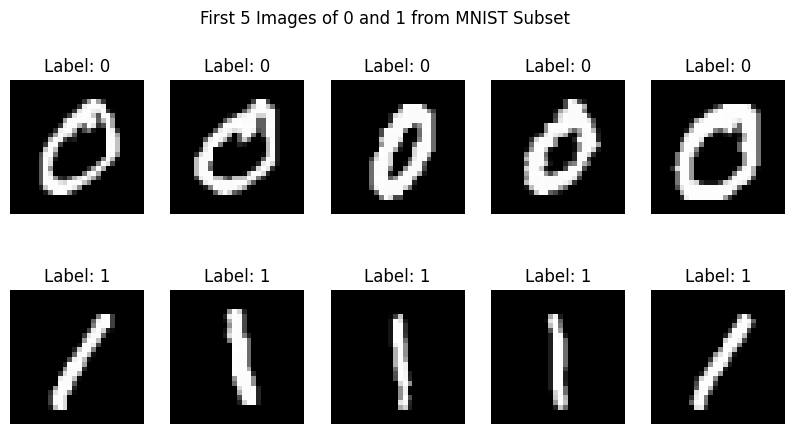

In [60]:
# Separate images for label 0 and label 1
images_0 = X[y == 0]  # Get all images with label 0
images_1 = X[y == 1]  # Get all images with label 1

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# Check if the arrays have the required amount of data
if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
    for i in range(5):
        # Plot digit 0
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")
        # Plot digit 1
        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")
    plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
    plt.show()

## Step - 2 - Initializing the Weights:

In [61]:
# Initialize weights and bias
weights = np.zeros(X.shape[1])  # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

## Step - 3 - Make a Decision function:

In [62]:
import numpy as np

def decision_function(X, weights, bias):
    """
    Compute the predicted labels for the input data.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - weights: Updated weights after training
    - bias: Updated bias after training

    Returns:
    - y_pred_all: The predicted labels for the input data
    """
    predictions = np.dot(X, weights) + bias
    #####Your Code Here############  # Activation function (step function)
    y_pred_all = np.where(predictions >= 0, 1, 0)

    return y_pred_all

## Step - 3 - Implement the Perceptron Learning Algorithm

In [63]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - y: Labels (true output) as a numpy array of shape (n_samples,)
    - weights: Initial weights as a numpy array of shape (n_features,)
    - bias: Initial bias value (scalar)
    - learning_rate: Learning rate for weight updates (default is 0.1)
    - epochs: Number of iterations to train the model (default is 100)

    Returns:
    - weights: Updated weights after training
    - bias: Updated bias after training
    - accuracy: Total correct prediction.
    """
    # Step 3: Perceptron Learning Algorithm
    # Your Code here#
    for epoch in range(epochs):
        correct = 0

        for i in range(len(X)):

            # Linear combination
            output = np.dot(X[i], weights) + bias

            # Step function
            y_pred = 1 if output >= 0 else 0

            # Update if wrong
            if y_pred != y[i]:
                weights = weights + learning_rate * (y[i] - y_pred) * X[i]
                bias = bias + learning_rate * (y[i] - y_pred)
            else:
                correct += 1

        # Optional: early stopping if perfect
        if correct == len(X):
            break

    accuracy = correct / len(X)

    return weights, bias, accuracy

# Q5: Purpose of `np.dot(X[i], weights) + bias`

This line calculates the weighted sum of inputs. It combines all input features with their corresponding weights and adds the bias to produce the final value used for prediction.

# Q6: What happens when prediction is wrong?

When the prediction is wrong, the weights and bias are updated. The update rule adjusts them in a way that reduces the error, helping the model make better predictions in future iterations.

# Q7: Why is final accuracy important?

Final accuracy shows how well the model is performing on the dataset. Since this is a simple binary classification problem (0 vs 1), we expect the accuracy to be very high, often close to 100%.

## Training the Perceptron

In [64]:
# After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

# Evaluate the model using the new function
print("The Final Accuracy is: ", accuracy)

The Final Accuracy is:  1.0


## Step 5: Visualize Misclassified Images

In [65]:
# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = decision_function(X, weights, bias)

# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):  # Show 10 misclassified images
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")

Final Accuracy: 1.0000
All images were correctly classified!


# Q8: What does `misclassified_idx` store?

It stores the indices of all samples where the predicted label is different from the actual label. These are the incorrectly classified images.

# Q9: If all images are correctly classified?

It means the model has perfectly learned to separate the two classes (0 and 1) with no errors on the dataset.

# Implementation for 3 Vs. 5 Classification.

## Step 1: Load the Dataset

In [66]:
df = pd.read_csv("/content/drive/MyDrive/Artificial Intelligence and Machine Learning/Week 3/mnist_3_and_5.csv")

df_3_5 = df[(df["label"] == 3) | (df["label"] == 5)]

X = df_3_5.drop("label", axis=1).values
y = df_3_5["label"].values

y = np.where(y == 5, 1, 0)

# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)


Feature matrix shape: (2741, 784)
Label vector shape: (2741,)


In [67]:
weights = np.zeros(X.shape[1])
bias = 0

In [68]:
def decision_function(X, weights, bias):
    predictions = np.dot(X, weights) + bias
    return np.where(predictions >= 0, 1, 0)

In [69]:
def train_perceptron(X, y, weights, bias, learning_rate=0.01, epochs=10):
    for epoch in range(epochs):
        correct = 0

        for i in range(len(X)):
            output = np.dot(X[i], weights) + bias

            # Binary prediction
            y_pred = 1 if output >= 0 else 0

            if y_pred == y[i]:
                correct += 1

            # Update rule
            weights = weights + learning_rate * (y[i] - y_pred) * X[i]
            bias = bias + learning_rate * (y[i] - y_pred)

        accuracy = correct / len(X)
        print(f"Epoch {epoch+1}, Accuracy: {accuracy:.4f}")

    return weights, bias, accuracy

In [70]:
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

print("Final Accuracy (3 vs 5):", accuracy)

Epoch 1, Accuracy: 0.9157
Epoch 2, Accuracy: 0.9372
Epoch 3, Accuracy: 0.9416
Epoch 4, Accuracy: 0.9475
Epoch 5, Accuracy: 0.9489
Epoch 6, Accuracy: 0.9504
Epoch 7, Accuracy: 0.9599
Epoch 8, Accuracy: 0.9559
Epoch 9, Accuracy: 0.9540
Epoch 10, Accuracy: 0.9566
Final Accuracy (3 vs 5): 0.9565851878876322


In [71]:
predictions = np.dot(X, weights) + bias

y_pred = decision_function(X, weights, bias)

y_pred_labels = np.where(y_pred == 1, 5, 3)
y_true_labels = np.where(y == 1, 5, 3)

final_accuracy = np.mean(y_pred_labels == y_true_labels)
print(f"Final Accuracy (3 vs 5): {final_accuracy:.4f}")

Final Accuracy (3 vs 5): 0.9613


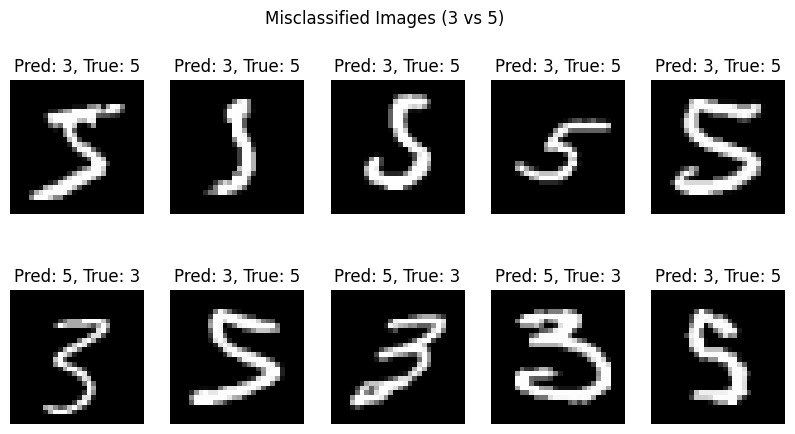

In [72]:
misclassified_idx = np.where(y_pred != y)[0]

if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))

    for ax, idx in zip(axes.flat, misclassified_idx[:10]):
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred_labels[idx]}, True: {y_true_labels[idx]}")
        ax.axis("off")

    plt.suptitle("Misclassified Images (3 vs 5)")
    plt.show()
else:
    print("All images were correctly classified!")

### Viewing the Dataset.

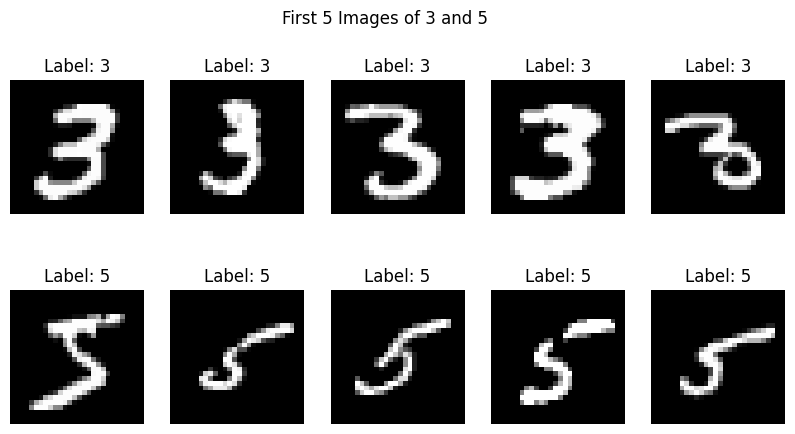

In [73]:
# Separate images correctly (0 → digit 3, 1 → digit 5)
images_3 = X[y == 0]
images_5 = X[y == 1]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

if len(images_3) < 5 or len(images_5) < 5:
    print("Error: Not enough images to display.")
else:
    for i in range(5):
        # Digit 3
        axes[0, i].imshow(images_3[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 3")
        axes[0, i].axis("off")

        # Digit 5
        axes[1, i].imshow(images_5[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 5")
        axes[1, i].axis("off")

    plt.suptitle("First 5 Images of 3 and 5")
    plt.show()